# Proyecto - Parte 1: Machine Learning clásico

## Clasificación de reseñas de productos en español (positivo / negativo / neutral)

**Estudiantes:**

Natalia erazo – 202213680

Ariadna Thais Vargas Contreras – 20221669

Samuel Montoya - 202320010

Felipe Sanmiguel - 202221528

**Curso:** ISIS2611 - Aprendizaje de Máquina

---

## Contexto y objetivo

El objetivo es clasificar reseñas de productos en español en tres clases (`positivo`, `negativo`, `neutral`) usando únicamente modelos clásicos de scikit-learn y representaciones de texto vistas en el curso (preprocesamiento, TF-IDF/bolsa de palabras y n-gramas), sin aprendizaje profundo, *transformers* ni *embeddings* preentrenados. El conjunto `train.csv` tiene 12.000 reseñas etiquetadas y `eval.csv` tiene las 3.000 reseñas de la competencia de Kaggle, que se evalúa con exactitud (*accuracy*).

**Modelo propuesto: `dos_etapas_nblr_robusto`.** Es un modelo en dos etapas que combina regresión logística, Naive Bayes, NB-LR (Naive Bayes + regresión logística, Wang y Manning, 2012) y dos arreglos de robustez (aumento de datos y detección de la oración con opinión). Obtuvo:

- **0,9081** de exactitud en una comparación justa de 15 particiones (3 repeticiones de validación cruzada de 5 particiones), la métrica más confiable con la que se cuenta.
- **0,91777** (826/900) en el puntaje público de Kaggle.

## Requisitos de la guía

| Requisito | Cómo se cumple |
|:---|:---|
| No usar aprendizaje profundo, *transformers* ni *embeddings* preentrenados. | No se usa ninguno. Todo se basa en TF-IDF, n-gramas y modelos lineales/probabilísticos clásicos (`LogisticRegression`, `MultinomialNB`). |
| Usar únicamente modelos de scikit-learn. | Los clasificadores son `LogisticRegression` y `MultinomialNB`. Las clases propias (`NBRegresionLogistica`, `ModeloDosEtapasNBLR`, `ExtraerConOpinion`, `ConAumento`) solo combinan y preparan datos con la interfaz `fit`/`predict`/`transform` de scikit-learn; no son redes neuronales ni modelos preentrenados. |
| Usar solo `train.csv` para entrenar y ajustar. | Todas las decisiones (arquitectura, hiperparámetros, arreglos de robustez) se tomaron con `train.csv` y validación cruzada. `eval.csv` solo se usa al final para generar las predicciones de la competencia. |
| Resultados replicables. | Semillas fijas (`RANDOM_STATE = 42`), versiones en `requirements.txt` y todo el flujo ejecutable en este notebook (ver la última sección). |


## 1. Del modelo base al modelo final: resumen del proceso y justificación de las decisiones

Antes de entrar al código, esta sección resume **por qué** el modelo final tiene la forma que tiene. Cada fila de la tabla es una decisión tomada con la misma regla de validación: una alternativa se adopta solo si mejora la exactitud en una comparación justa de 15 particiones (3 repeticiones de validación cruzada de 5 particiones sobre las 12.000 reseñas), con una diferencia media mayor a 2 errores estándar y ganando en al menos 12 de las 15 particiones. Si no cumple eso, se considera un empate y se mantiene la opción más simple.

| Paso | Decisión | Justificación (exactitud, 15 particiones salvo que se indique otra cosa) |
|:---|:---|:---|
| 1. Representación del texto | Dividir cada reseña en **tres bloques** (texto completo, última oración, cláusula final tras el último conector de contraste) en vez de usar solo TF-IDF del texto completo | El análisis de errores mostró que la etiqueta casi siempre la define la opinión al **final** de la reseña (F1-macro de solo la última oración: 0,860, contra 0,517 de solo la primera). Pasar de texto completo a la representación por bloques subió el F1-macro de validación de 0,744 a 0,894: es la mejora más grande de todo el proceso. |
| 2. Preprocesamiento | Quitar tildes y signos de puntuación; **no** quitar *stop words* de NLTK | Las *stop words* genéricas eliminan palabras que cargan la polaridad en español ("no", "pero", "muy", "sin") y empeoran el modelo. El *stemming* no cambia el resultado, así que se deja por consistencia con los bloques. |
| 3. Corrección de un error de la representación | No cortar la cláusula final en "al final de cuentas" / "a fin de cuentas" | Esas expresiones casi siempre son muletillas, no conectores de contraste; cortar ahí dejaba la cláusula final vacía en ~3,5% de las reseñas. Corregirlo mejora +0,21 puntos, ganando en las 15 de 15 particiones. |
| 4. Algoritmo sobre la representación por bloques | Regresión logística con penalización L1 en vez de Naive Bayes, Random Forest, KNN o árbol de decisión | Sobre la misma representación, la regresión logística obtiene 0,895 de exactitud en prueba contra 0,886 (Naive Bayes), 0,841 (Random Forest), 0,796 (KNN) y 0,674 (árbol). Los modelos de ensamble de árboles rinden mal sobre texto disperso de alta dimensión. |
| 5. Ponderación de atributos | **NB-LR**: multiplicar cada n-grama por la razón de verosimilitud de Naive Bayes antes de la regresión logística (Wang y Manning, 2012) | Mejora +0,37 puntos sobre el modelo de regresión logística por bloques (13 de 15 particiones): la ponderación ayuda a la regresión logística a dar más peso a los n-gramas que de verdad distinguen cada clase. |
| 6. Arquitectura | **Modelo en dos etapas**: puntuar cada *trozo* de la reseña con un primer clasificador y decidir la etiqueta con una segunda regresión logística sobre esos puntajes y las probabilidades de los modelos por bloques (regresión logística, Naive Bayes y NB-LR) | Permite que el modelo use explícitamente la posición de la opinión dentro de la reseña (qué trozo es el último, si viene después de un conector) en vez de solo la bolsa de palabras global. Combinado con NB-LR llega a 0,9023 (+0,56 sobre el modelo de bloques, 14 de 15 particiones): es el mejor modelo antes de los arreglos de robustez. |
| 7. Ensambles probados (votación suave, apilamiento, Random Forest/Gradient Boosting sobre texto, interacciones de orden 2 en la etapa 2) | **Descartados** | Ninguno supera al modelo en dos etapas + NB-LR con la regla de decisión: o empatan, o son notablemente más lentos sin ganar, o rinden peor (Random Forest, Gradient Boosting, árboles en la etapa 2). |
| 8. Diagnóstico | Encontrar la debilidad del modelo: una frase **sin opinión al final** de la reseña (p. ej. "Viene en color negro.") hace caer la exactitud de 0,90 a entre 0,63 y 0,71, porque el modelo aprendió asociaciones espurias entre el tema de la última oración y la etiqueta | Motiva los dos arreglos de robustez que dan el modelo final. |
| 9. Arreglos de robustez | **(A) Aumento de datos**: agregar al final de la mitad de las reseñas de entrenamiento una oración de una reseña neutral, sin cambiar la etiqueta. **(B) Última oración con opinión**: usar, en los bloques de "última oración" y "cláusula final", la última oración que un detector (opinión vs. hecho) considere que tiene opinión, en vez de la última oración por posición | Por separado, A no mejora la exactitud normal (empata, su objetivo es la robustez) y B mejora pero se queda justo debajo del umbral de la regla (11 de 15). **Juntos (A + B) sí mejoran**: +0,59 puntos sobre el modelo en dos etapas + NB-LR (14 de 15 particiones, llegando a 0,9081), y además corrigen la debilidad: con una frase neutra al final la exactitud ahora baja solo 0,1–0,2 puntos en vez de 20–40. |

**Modelo elegido: `dos_etapas_nblr_robusto`** (modelo en dos etapas + NB-LR + arreglos A y B). Es el mejor en la comparación justa de 15 particiones (0,9081) y tiene un puntaje público de Kaggle de 0,91777.


## 2. Importación de librerías

In [1]:
import os
import re
import unicodedata
import warnings
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.stem import SnowballStemmer
from scipy import sparse

from sklearn.base import BaseEstimator, ClassifierMixin, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_score, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 120)
pd.set_option('display.width', 160)

RANDOM_STATE = 42
ORDEN_CLASES = ['negativo', 'neutral', 'positivo']

# Rutas del proyecto (este notebook está en la carpeta notebooks/)
RUTA_DATOS = os.path.join('..', 'data')
RUTA_MODELOS = os.path.join('..', 'models')
RUTA_ENVIOS = os.path.join('..', 'submissions')
os.makedirs(RUTA_MODELOS, exist_ok=True)
os.makedirs(RUTA_ENVIOS, exist_ok=True)

## 3. Datos y partición

Se usa la partición 80/20 estratificada (semilla 42) que se usa en todo el proyecto. El 20% de prueba (`X_test`, `y_test`) no se usa para tomar ninguna decisión: solo sirve para medir el desempeño final en las secciones 7 y 8. La comparación de 15 particiones (sección 9) usa las 12.000 reseñas directamente, con sus propias particiones.

In [2]:
train = pd.read_csv(os.path.join(RUTA_DATOS, 'train.csv'))
evaluacion = pd.read_csv(os.path.join(RUTA_DATOS, 'eval.csv'))
muestra_envio = pd.read_csv(os.path.join(RUTA_DATOS, 'sample_submission.csv'))

print('train:', train.shape, '| eval:', evaluacion.shape, '| sample_submission:', muestra_envio.shape)
print('Distribución de clases en train:')
display(train['label'].value_counts(normalize=True).reindex(ORDEN_CLASES).round(3).to_frame('proporción'))

X = train[['text']]
y = train['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)

train: (12000, 3) | eval: (3000, 2) | sample_submission: (3000, 2)
Distribución de clases en train:


,proporción
label,
negativo,0.351
neutral,0.298
positivo,0.351


Entrenamiento: (9600, 1) | Prueba: (2400, 1)


## 4. Preprocesamiento y representación del texto por bloques

El preprocesamiento (minúsculas, quitar tildes y signos de puntuación, *stemming* con `SnowballStemmer`, sin *stop words*) es el del notebook principal del proyecto (justificado en la sección 1, paso 2).

La representación divide cada reseña en **tres bloques**, cada uno vectorizado por separado con TF-IDF (unigramas y bigramas) y concatenados con un `ColumnTransformer`:

1. **`completo`**: el texto completo de la reseña.
2. **`ultima`**: solo la última oración, donde casi siempre está la opinión que define la etiqueta.
3. **`clausula`**: la cláusula final de la última oración, es decir, lo que viene después del último conector de contraste (`pero`, `aunque`, `sin embargo`, `aun así`, `con todo`, `al final`, excepto cuando "al final" es parte de la muletilla "al final de cuentas" — la corrección de la sección 1, paso 3).

In [3]:
stemmer = SnowballStemmer('spanish')
cache_raices = {}


def raiz(palabra):
    # Se guarda la raíz de cada palabra para no repetir el stemming miles de veces
    if palabra not in cache_raices:
        cache_raices[palabra] = stemmer.stem(palabra)
    return cache_raices[palabra]


def quitar_tildes(texto):
    texto = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in texto if not unicodedata.combining(c))


def limpiar_texto(texto, stop=None, stemming=True):
    texto = quitar_tildes(texto.lower())
    texto = re.sub(r'[^\w\s]', ' ', texto)
    texto = re.sub(r'\d+', ' ', texto)
    tokens = texto.split()
    if stop:
        tokens = [t for t in tokens if t not in stop]
    if stemming:
        tokens = [raiz(t) for t in tokens]
    return ' '.join(tokens)


def separar_oraciones(texto):
    return [o.strip() for o in re.split(r'(?<=[.!?])\s+', texto) if o.strip()]


def extraer_completo(textos, stemming=True):
    return [limpiar_texto(t, stemming=stemming) for t in textos]


def extraer_ultima(textos, stemming=True):
    return [limpiar_texto(separar_oraciones(t)[-1], stemming=stemming) for t in textos]


def bloque_tfidf(nombre, extractor, rango=(1, 2)):
    return (nombre,
            Pipeline([('extraer', FunctionTransformer(extractor)),
                      ('tfidf', TfidfVectorizer(ngram_range=rango))]),
            'text')

In [4]:
# "al final de cuentas" y "a fin de cuentas" suelen ser muletillas al final de la frase, no conectores.
# Se deja de cortar ahí y, si el corte deja un fragmento de menos de 3 palabras, se toma el anterior.
CONECTORES_CORREGIDOS = r'\b(?:pero|aunque|sin embargo|aun asi|con todo|al final(?! de cuentas))\b'


def ultimo_fragmento(oracion, min_palabras=3):
    partes = [p for p in re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower())) if len(p.split()) >= min_palabras]
    return partes[-1] if partes else oracion


def extraer_clausula_corregida(textos, stemming=True):
    return [limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]), stemming=stemming) for t in textos]


def construir_representacion_corregida(rango=(1, 2)):
    return ColumnTransformer([bloque_tfidf('completo', extraer_completo, rango),
                              bloque_tfidf('ultima', extraer_ultima, rango),
                              bloque_tfidf('clausula', extraer_clausula_corregida, rango)])


def metricas(y_real, y_pred):
    return {'Exactitud': accuracy_score(y_real, y_pred),
            'Precisión (macro)': precision_score(y_real, y_pred, average='macro'),
            'Recall (macro)': recall_score(y_real, y_pred, average='macro'),
            'F1 (macro)': f1_score(y_real, y_pred, average='macro')}

## 5. NB-LR: regresión logística con atributos ponderados por Naive Bayes

NB-LR (Wang y Manning, 2012) parte de la misma representación por bloques, pero con **presencia o ausencia** de cada n-grama (`CountVectorizer(binary=True)`) en vez de TF-IDF. Para cada clase (una contra el resto):

1. Se calcula, como en Naive Bayes multinomial, qué tan frecuente es cada n-grama en las reseñas de la clase y en las del resto (con suavizado `alpha`).
2. Cada atributo se multiplica por el logaritmo de la razón entre esas dos frecuencias (la "razón de Naive Bayes").
3. Sobre esos atributos ponderados se entrena una regresión logística binaria (una por clase), y las probabilidades se normalizan para que sumen 1.

La idea es que la regresión logística, que por sí sola trata todos los n-gramas por igual al principio, parta ya informada de qué tan discriminativo es cada uno para cada clase, en vez de tener que aprenderlo solo a partir de los datos de entrenamiento.

In [5]:
def construir_bolsas_binarias(rango=(1, 2)):
    # Los mismos tres bloques, pero con presencia/ausencia de cada n-grama en lugar de TF-IDF
    extractores = {'completo': extraer_completo, 'ultima': extraer_ultima, 'clausula': extraer_clausula_corregida}
    return ColumnTransformer([
        (nombre, Pipeline([('extraer', FunctionTransformer(extractor)),
                           ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text')
        for nombre, extractor in extractores.items()
    ])


class NBRegresionLogistica(ClassifierMixin, BaseEstimator):
    '''Regresión logística sobre atributos ponderados con la razón de Naive Bayes (NB-LR).

    Para cada clase (una contra el resto) cada atributo se multiplica por
    log(P(atributo | clase) / P(atributo | resto)), calculado con suavizado alpha como en
    MultinomialNB, y sobre esos atributos se entrena una regresión logística.
    '''

    def __init__(self, C=0.3, alpha=1.0):
        self.C = C
        self.alpha = alpha

    def fit(self, X, y):
        X = sparse.csr_matrix(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        self.razones_, self.modelos_ = [], []
        for clase in self.classes_:
            es_clase = y == clase
            p = self.alpha + np.asarray(X[es_clase].sum(axis=0)).ravel()
            q = self.alpha + np.asarray(X[~es_clase].sum(axis=0)).ravel()
            razon = np.log((p / p.sum()) / (q / q.sum()))
            modelo = LogisticRegression(C=self.C, max_iter=3000)
            modelo.fit(X.multiply(razon).tocsr(), es_clase.astype(int))
            self.razones_.append(razon)
            self.modelos_.append(modelo)
        return self

    def predict_proba(self, X):
        X = sparse.csr_matrix(X, dtype=float)
        P = np.column_stack([m.predict_proba(X.multiply(r).tocsr())[:, 1]
                             for m, r in zip(self.modelos_, self.razones_)])
        return P / P.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

## 6. Modelo en dos etapas (`ModeloDosEtapasNBLR`)

**Intuición.** En vez de clasificar la reseña completa de una sola vez, el modelo primero puntúa cada **trozo** del texto (cada oración, partida además en los puntos donde aparece un conector de contraste como "pero") y después usa esos puntajes, junto con las probabilidades de los modelos por bloques, para decidir la etiqueta final. Esto deja que el modelo use explícitamente señales como "¿cuál es el sentimiento del último trozo?" o "¿el trozo viene después de un 'pero'?", que son justo las que un lector humano usaría.

**Etapa 1 — puntuar trozos.** Se entrena una regresión logística sobre TF-IDF (unigramas y bigramas) donde cada **trozo** de cada reseña de entrenamiento hereda la etiqueta de la reseña completa. Esto da, para cualquier trozo de texto, una probabilidad de `negativo`/`neutral`/`positivo`.

**Etapa 2 — combinar señales.** Para cada reseña se construye un vector de atributos con:

- Las probabilidades de los **tres modelos por bloques** entrenados sobre toda la reseña: regresión logística L1, Naive Bayes y NB-LR.
- Las probabilidades de la etapa 1 para los **últimos 4 trozos** de la reseña (y si viene o no después de un conector), porque son los que normalmente contienen la opinión que decide la etiqueta.
- Resúmenes sobre los trozos **con opinión** (los que la etapa 1 no clasifica como `neutral`): la polaridad del último, el penúltimo y el primero con opinión, cuántos hay en total, y la probabilidad máxima de cada clase.
- Indicadores de si la oración con opinión empieza con alguno de los **12 comienzos de oración más frecuentes** del corpus (p. ej. "sin embargo", "en general"), que capturan patrones retóricos recurrentes.

Sobre ese vector (estandarizado) se entrena una regresión logística con regularización fuerte (`C_etapa2 = 0,1`), que aprende a combinar todas esas señales.

**Por qué se calculan los atributos de la etapa 2 fuera de muestra.** Si la etapa 2 se entrenara con las probabilidades que la etapa 1 (y los modelos por bloques) dan sobre las *mismas* reseñas con las que se entrenaron, esas probabilidades estarían artificialmente ajustadas a esos datos y la etapa 2 aprendería a confiar en ellas más de lo que debería (una forma de fuga de información interna). Por eso `fit` hace una validación cruzada interna de 5 particiones: en cada partición se entrenan los modelos de la etapa 1 solo con el 80% de los datos y se calculan sus atributos sobre el 20% restante, que no vieron. Así la etapa 2 se entrena con atributos "honestos", del mismo tipo que verá en producción.

Esta arquitectura es la base del **modelo en dos etapas + NB-LR**, que ya por sí solo (sin los arreglos de robustez de la sección 8) llega a 0,9023 de exactitud en la comparación de 15 particiones.

In [6]:
K_ULTIMOS = 4          # cuántos de los últimos trozos se usan como atributos
N_INICIOS = 12         # cuántos comienzos de oración frecuentes se usan como atributos


def separar_trozos(texto):
    '''Parte cada oración en trozos usando los conectores de contraste.
    Devuelve una lista de (trozo, tras_conector); tras_conector vale 1 si el trozo viene después de un conector.'''
    trozos = []
    for oracion in separar_oraciones(texto):
        partes = re.split(CONECTORES_CORREGIDOS, quitar_tildes(oracion.lower()))
        for i, parte in enumerate(partes):
            if parte.strip():
                trozos.append((parte.strip(), int(i > 0)))
    return trozos


def entrenar_etapa1(textos, etiquetas, C):
    trozos, etiquetas_trozos = [], []
    for texto, etiqueta in zip(textos, etiquetas):
        for trozo, _ in separar_trozos(texto):
            trozos.append(limpiar_texto(trozo))
            etiquetas_trozos.append(etiqueta)    # cada trozo hereda la etiqueta de su reseña
    vectorizador = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
    clasificador = LogisticRegression(C=C, max_iter=2000)
    clasificador.fit(vectorizador.fit_transform(trozos), etiquetas_trozos)
    return vectorizador, clasificador


def comienzo_oracion(oracion):
    palabras = re.sub(r'[^\w\s]', '', quitar_tildes(oracion.lower())).split()
    return ' '.join(palabras[:2])


def comienzos_frecuentes(textos, n=N_INICIOS):
    conteo = Counter(comienzo_oracion(o) for t in textos for o in separar_oraciones(t)[1:])
    return [c for c, _ in conteo.most_common(n)]

In [7]:
class ModeloDosEtapasNBLR(ClassifierMixin, BaseEstimator):
    '''Modelo en dos etapas al que se le agregan las probabilidades de NB-LR.

    Etapa 1: puntúa cada trozo de la reseña (probabilidad de negativo, neutral y positivo).
    Etapa 2: regresión logística sobre los puntajes de los últimos trozos, las probabilidades de los
    modelos por bloques (regresión logística, Naive Bayes y NB-LR) y el comienzo de las oraciones con opinión.
    '''

    def __init__(self, C_etapa1=3, C_etapa2=1, C_nblr=0.3, alpha_nblr=1.0, n_particiones=5, random_state=42):
        self.C_etapa1 = C_etapa1
        self.C_etapa2 = C_etapa2
        self.C_nblr = C_nblr
        self.alpha_nblr = alpha_nblr
        self.n_particiones = n_particiones
        self.random_state = random_state

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_corregida().fit(datos)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

    def _caracteristicas(self, textos, comp):
        datos = pd.DataFrame({'text': textos.values})
        matriz = comp['representacion'].transform(datos)
        prob_regresion = comp['regresion'].predict_proba(matriz)
        prob_bayes = comp['bayes'].predict_proba(matriz)
        prob_nblr = comp['nblr'].predict_proba(datos)

        trozos_por_texto = [separar_trozos(t) for t in textos]
        oraciones_por_texto = [separar_oraciones(t) for t in textos]
        probs_trozos = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(trozo) for lista in trozos_por_texto for trozo, _ in lista]))
        probs_oraciones = comp['clasificador'].predict_proba(comp['vectorizador'].transform(
            [limpiar_texto(o) for lista in oraciones_por_texto for o in lista]))

        filas = []
        ini_t = ini_o = 0
        for k in range(len(textos)):
            trozos, oraciones = trozos_por_texto[k], oraciones_por_texto[k]
            P = probs_trozos[ini_t:ini_t + len(trozos)]
            Po = probs_oraciones[ini_o:ini_o + len(oraciones)]
            ini_t += len(trozos)
            ini_o += len(oraciones)

            fila = list(prob_regresion[k])
            for j in range(1, K_ULTIMOS + 1):
                if j <= len(trozos):
                    fila += list(P[-j]) + [trozos[-j][1]]
                else:
                    fila += [0, 0, 0, 0]
            polaridad = P[:, 2] - P[:, 0]
            con_opinion = np.where(P[:, 1] < 0.5)[0]
            fila += [polaridad[con_opinion[-1]] if len(con_opinion) > 0 else 0,
                     polaridad[con_opinion[-2]] if len(con_opinion) > 1 else 0,
                     polaridad[con_opinion[0]] if len(con_opinion) > 0 else 0,
                     len(con_opinion), P[:, 2].max(), P[:, 0].max(), P[:, 1].mean(), len(trozos)]
            fila += list(prob_bayes[k])
            oraciones_con_opinion = np.where(Po[:, 1] < 0.5)[0]
            for pos in [-1, -2]:
                comienzo = ''
                if len(oraciones_con_opinion) >= -pos:
                    comienzo = comienzo_oracion(oraciones[oraciones_con_opinion[pos]])
                fila += [int(comienzo == c) for c in self.comienzos_]
            fila += list(prob_nblr[k])
            filas.append(fila)
        return np.array(filas)

    def fit(self, X, y):
        textos = pd.Series(np.asarray(X['text']))
        etiquetas = pd.Series(np.asarray(y))
        self.classes_ = np.array(sorted(etiquetas.unique()))
        self.comienzos_ = comienzos_frecuentes(textos)

        # Atributos de la etapa 2 calculados fuera de muestra (validación cruzada interna)
        particiones = StratifiedKFold(n_splits=self.n_particiones, shuffle=True, random_state=self.random_state)
        caracteristicas = None
        for idx_ent, idx_val in particiones.split(textos, etiquetas):
            comp = self._entrenar_componentes(textos.iloc[idx_ent], etiquetas.iloc[idx_ent])
            fila_val = self._caracteristicas(textos.iloc[idx_val], comp)
            if caracteristicas is None:
                caracteristicas = np.zeros((len(textos), fila_val.shape[1]))
            caracteristicas[idx_val] = fila_val

        self.etapa2_ = Pipeline([('escala', StandardScaler()),
                                 ('modelo', LogisticRegression(C=self.C_etapa2, max_iter=3000))])
        self.etapa2_.fit(caracteristicas, etiquetas)
        self.componentes_ = self._entrenar_componentes(textos, etiquetas)
        return self

    def predict_proba(self, X):
        textos = pd.Series(np.asarray(X['text']))
        return self.etapa2_.predict_proba(self._caracteristicas(textos, self.componentes_))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(axis=1)]

## 7. La debilidad del modelo y los dos arreglos de robustez

Un diagnóstico del modelo en dos etapas + NB-LR (sin arreglos) encontró su principal debilidad: si se agrega al final de una reseña una frase **sin opinión** (p. ej. "Viene en color negro."), la exactitud cae de 0,90 a entre 0,63 y 0,71. El modelo aprendió que la última oración decide la etiqueta y lo aplica aunque esa oración no opine de nada. Esto no afecta a la competencia (las reseñas de `eval.csv` tienen la misma estructura que las de entrenamiento), pero sí sería un problema con reseñas reales, que con frecuencia terminan en comentarios neutros (sobre el empaque, el envío, el uso diario, etc.).

Se prueban dos arreglos:

- **Arreglo A — aumento de datos.** A la mitad de las reseñas de entrenamiento (elegidas al azar) se les agrega al final una oración tomada de una reseña neutral del mismo conjunto, **sin cambiar su etiqueta**. Así el modelo ve ejemplos donde la última oración no decide, y aprende a no depender ciegamente de ella. Se modifican reseñas existentes en vez de duplicarlas, para que la validación cruzada interna de la etapa 2 no vea casi la misma reseña en entrenamiento y en validación.
- **Arreglo B — última oración con opinión.** En vez de usar siempre la última oración por posición, se usa la última oración que un **detector de opinión** (una regresión logística sobre TF-IDF, entrenada para distinguir "opinión" de "hecho") considere que sí tiene opinión. El detector se entrena con las oraciones de las reseñas neutrales como ejemplos de "hecho" y con la cláusula final de las reseñas positivas/negativas como ejemplos de "opinión", usando siempre probabilidades fuera de muestra (validación cruzada agrupada por reseña) para no memorizar las cláusulas con que se entrenó.

Los dos arreglos se combinan (A + B) y se aplican tanto a la regresión logística por bloques como al modelo en dos etapas + NB-LR, dando el modelo final: `dos_etapas_nblr_robusto`.

In [8]:
FRASES_NEUTRAS = ['Lo uso casi todos los días en la oficina.', 'El paquete llegó en una caja de cartón.',
                  'Lo compré por internet hace un mes.', 'Viene en color negro.']


def versiones_con_frase(textos, etiquetas, semilla=0):
    '''El texto original, el texto con cada frase neutra al final y el texto con una oración de una reseña neutral
    del mismo conjunto (que el modelo no vio al entrenarse) al final.'''
    textos, etiquetas = list(textos), np.asarray(etiquetas)
    rng = np.random.default_rng(semilla)
    banco = [o for t, e in zip(textos, etiquetas) if e == 'neutral' for o in separar_oraciones(t) if len(o.split()) >= 4]
    versiones = {'original': textos}
    for i, frase in enumerate(FRASES_NEUTRAS):
        versiones[f'+ "{frase}"'] = [t.rstrip() + ' ' + frase for t in textos]
    versiones['+ oración de una reseña neutral'] = [t.rstrip() + ' ' + banco[rng.integers(len(banco))] for t in textos]
    return versiones


def exactitud_por_version(modelo, versiones, etiquetas):
    return {v: accuracy_score(etiquetas, modelo.predict(pd.DataFrame({'text': textos}))) for v, textos in versiones.items()}


versiones_test = versiones_con_frase(X_test['text'], y_test)
modelo_sin_arreglos = ModeloDosEtapasNBLR(C_etapa2=0.1).fit(X_train, y_train)
modelo_lr = Pipeline([('rep', construir_representacion_corregida()),
                      ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                    random_state=RANDOM_STATE))]).fit(X_train, y_train)
antes = pd.DataFrame({'Dos etapas + NB-LR (sin arreglos)': exactitud_por_version(modelo_sin_arreglos, versiones_test, y_test),
                      'Regresión logística (sin arreglos)': exactitud_por_version(modelo_lr, versiones_test, y_test)})
antes.round(4)

,Dos etapas + NB-LR (sin arreglos),Regresión logística (sin arreglos)
original,0.8992,0.8954
"+ ""Lo uso casi todos los días en la oficina.""",0.6696,0.6821
"+ ""El paquete llegó en una caja de cartón.""",0.6683,0.5400
"+ ""Lo compré por internet hace un mes.""",0.7000,0.6717
"+ ""Viene en color negro.""",0.6154,0.4929
+ oración de una reseña neutral,0.6521,0.6033


In [9]:
def aumentar(textos, etiquetas, proporcion=0.5, semilla=0):
    '''Agrega al final de una proporción de las reseñas una oración tomada de reseñas neutrales (sin cambiar la etiqueta).'''
    rng = np.random.default_rng(semilla)
    banco = [o for t, e in zip(textos, etiquetas) if e == 'neutral' for o in separar_oraciones(t) if len(o.split()) >= 4]
    return [t.rstrip() + ' ' + banco[rng.integers(len(banco))] if rng.random() < proporcion else t for t in textos]


class ConAumento(ClassifierMixin, BaseEstimator):
    '''Entrena el modelo con el arreglo A aplicado solo a los datos de entrenamiento. Al predecir no cambia nada.'''

    def __init__(self, modelo, proporcion=0.5, random_state=0):
        self.modelo = modelo
        self.proporcion = proporcion
        self.random_state = random_state

    def fit(self, X, y):
        textos = aumentar(list(X['text']), np.asarray(y), self.proporcion, self.random_state)
        self.modelo_ = clone(self.modelo).fit(pd.DataFrame({'text': textos}), np.asarray(y))
        self.classes_ = self.modelo_.classes_
        return self

    def predict_proba(self, X):
        return self.modelo_.predict_proba(X)

    def predict(self, X):
        return self.modelo_.predict(X)

In [10]:
class ExtraerConOpinion(BaseEstimator, TransformerMixin):
    '''Devuelve, limpia, la última oración con opinión de cada reseña (o su cláusula final).

    Un detector distingue "opinión" de "hecho": una regresión logística sobre TF-IDF entrenada con las oraciones de
    reseñas neutrales (hecho) y con la cláusula final de las reseñas positivas o negativas (casi siempre una opinión).
    Una oración tiene opinión si P(opinión) > umbral. Si ninguna la tiene, se usa la última oración.
    Para las oraciones de entrenamiento se usa la probabilidad fuera de muestra (validación cruzada agrupada por
    reseña); si no, el detector las reconocería de memoria.
    '''

    def __init__(self, parte='ultima', umbral=0.5, stemming=True):
        self.parte = parte
        self.umbral = umbral
        self.stemming = stemming

    def fit(self, X, y):
        textos, y = list(np.asarray(X)), np.asarray(y)
        frases, etiquetas, grupo = [], [], []
        for i, (t, e) in enumerate(zip(textos, y)):
            if e == 'neutral':
                for o in separar_oraciones(t):
                    frases.append(limpiar_texto(o)); etiquetas.append(0); grupo.append(i)
            else:
                frases.append(limpiar_texto(ultimo_fragmento(separar_oraciones(t)[-1]))); etiquetas.append(1); grupo.append(i)
        frases, etiquetas, grupo = np.array(frases, dtype=object), np.array(etiquetas), np.array(grupo)
        self.fuera_de_muestra_ = {}
        for a, b in GroupKFold(n_splits=5).split(frases, etiquetas, grupo):
            vec = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
            m = LogisticRegression(C=1, max_iter=2000).fit(vec.fit_transform(frases[a]), etiquetas[a])
            for o, p in zip(frases[b], m.predict_proba(vec.transform(frases[b]))[:, 1]):
                self.fuera_de_muestra_[o] = p
        self.vectorizador_ = TfidfVectorizer(ngram_range=(1, 2), min_df=2)
        self.detector_ = LogisticRegression(C=1, max_iter=2000).fit(self.vectorizador_.fit_transform(frases), etiquetas)
        return self

    def prob_opinion(self, oraciones_limpias):
        faltan = [o for o in oraciones_limpias if o not in self.fuera_de_muestra_]
        nuevas = dict(zip(faltan, self.detector_.predict_proba(self.vectorizador_.transform(faltan))[:, 1])) if faltan else {}
        return np.array([self.fuera_de_muestra_.get(o, nuevas.get(o)) for o in oraciones_limpias])

    def oracion_con_opinion(self, texto):
        oraciones = separar_oraciones(texto)
        p = self.prob_opinion([limpiar_texto(o) for o in oraciones])
        con_opinion = np.where(p > self.umbral)[0]
        return oraciones[con_opinion[-1]] if len(con_opinion) else oraciones[-1]

    def transform(self, X):
        salida = []
        for t in np.asarray(X):
            o = self.oracion_con_opinion(t)
            if self.parte == 'clausula':
                o = ultimo_fragmento(o)
            salida.append(limpiar_texto(o, stemming=self.stemming))
        return salida


def construir_representacion_opinion(rango=(1, 2)):
    return ColumnTransformer([
        ('completo', Pipeline([('extraer', FunctionTransformer(extraer_completo)), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
        ('ultima', Pipeline([('extraer', ExtraerConOpinion('ultima')), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
        ('clausula', Pipeline([('extraer', ExtraerConOpinion('clausula')), ('tfidf', TfidfVectorizer(ngram_range=rango))]), 'text'),
    ])


def construir_bolsas_binarias_opinion(rango=(1, 2)):
    return ColumnTransformer([
        ('completo', Pipeline([('extraer', FunctionTransformer(extraer_completo)), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
        ('ultima', Pipeline([('extraer', ExtraerConOpinion('ultima')), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
        ('clausula', Pipeline([('extraer', ExtraerConOpinion('clausula')), ('conteo', CountVectorizer(ngram_range=rango, binary=True))]), 'text'),
    ])


class ModeloDosEtapasNBLROpinion(ModeloDosEtapasNBLR):
    '''Modelo en dos etapas + NB-LR con los bloques de última oración y cláusula final tomados de la
    última oración con opinión (arreglo B). Es la clase base del modelo final junto con ConAumento (arreglo A).'''

    def _entrenar_componentes(self, textos, etiquetas):
        datos = pd.DataFrame({'text': textos.values})
        representacion = construir_representacion_opinion().fit(datos, etiquetas)
        matriz = representacion.transform(datos)
        regresion = LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                       random_state=RANDOM_STATE).fit(matriz, etiquetas)
        bayes = MultinomialNB(alpha=0.3).fit(matriz, etiquetas)
        nblr = Pipeline([('rep', construir_bolsas_binarias_opinion()),
                         ('modelo', NBRegresionLogistica(C=self.C_nblr, alpha=self.alpha_nblr))]).fit(datos, etiquetas)
        vectorizador, clasificador = entrenar_etapa1(textos, etiquetas, self.C_etapa1)
        return {'representacion': representacion, 'regresion': regresion, 'bayes': bayes, 'nblr': nblr,
                'vectorizador': vectorizador, 'clasificador': clasificador}

**`dos_etapas_nblr_robusto` = `ConAumento(ModeloDosEtapasNBLROpinion(...))`.** Es decir: el modelo en dos etapas + NB-LR de la sección 6, pero con los bloques de "última oración" y "cláusula final" calculados con el detector de opinión (arreglo B), y entrenado con la mitad de las reseñas de entrenamiento aumentadas con una frase neutra (arreglo A). `predict` no cambia: los arreglos solo afectan cómo se entrena el modelo, no cómo predice.

**Reproducción del problema (con los modelos entrenados solo en el 80% de entrenamiento).** La siguiente celda confirma, en el conjunto de prueba, que una frase neutra al final hace caer la exactitud de los modelos sin arreglos entre 20 y 40 puntos (tabla `antes` de la celda anterior) y mide cuánto la recuperan los arreglos A + B.

,Regresión logística (sin arreglos),Regresión logística + A + B,Dos etapas + NB-LR (sin arreglos),Dos etapas + NB-LR + A + B (modelo final)
original,0.8954,0.9058,0.8992,0.9062
"+ ""Lo uso casi todos los días en la oficina.""",0.6821,0.9042,0.6696,0.9062
"+ ""El paquete llegó en una caja de cartón.""",0.5400,0.9017,0.6683,0.9071
"+ ""Lo compré por internet hace un mes.""",0.6717,0.8954,0.7000,0.9050
"+ ""Viene en color negro.""",0.4929,0.9054,0.6154,0.9058
+ oración de una reseña neutral,0.6033,0.8962,0.6521,0.9017


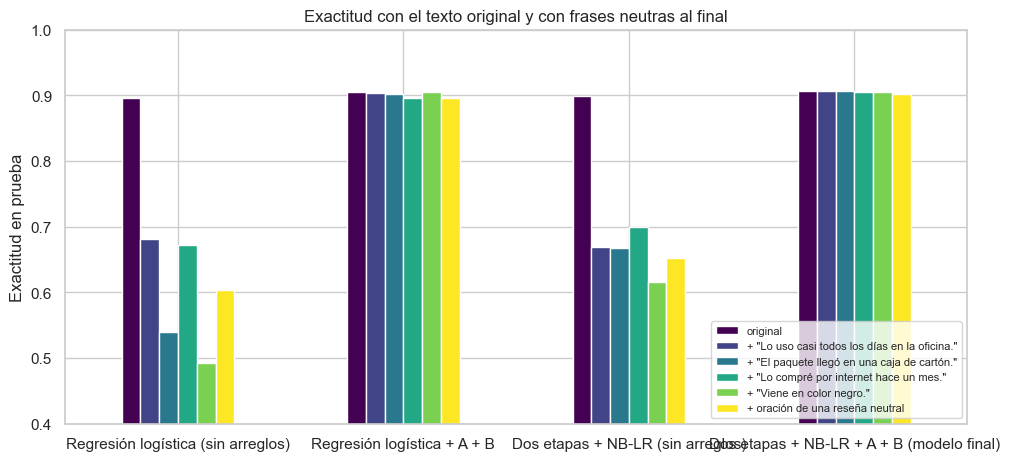

In [11]:
modelo_lr_robusta = ConAumento(Pipeline([('rep', construir_representacion_opinion()),
                                         ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                                       random_state=RANDOM_STATE))]))
modelo_robusto_80 = ConAumento(ModeloDosEtapasNBLROpinion(C_etapa2=0.1))
modelo_lr_robusta.fit(X_train, y_train)
modelo_robusto_80.fit(X_train, y_train)

despues = pd.DataFrame({'Regresión logística + A + B': exactitud_por_version(modelo_lr_robusta, versiones_test, y_test),
                        'Dos etapas + NB-LR + A + B (modelo final)': exactitud_por_version(modelo_robusto_80, versiones_test, y_test)})
tabla_test = pd.concat([antes, despues], axis=1)[['Regresión logística (sin arreglos)', 'Regresión logística + A + B',
                                                  'Dos etapas + NB-LR (sin arreglos)', 'Dos etapas + NB-LR + A + B (modelo final)']]
display(tabla_test.round(4))

fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
tabla_test.T.plot(kind='bar', ax=ax, legend=False, colormap='viridis')
ax.set(ylabel='Exactitud en prueba', ylim=(0.4, 1), title='Exactitud con el texto original y con frases neutras al final')
ax.legend(loc='lower right', fontsize=8)
plt.xticks(rotation=0)
plt.show()

Con una frase neutra al final, el modelo final (`Dos etapas + NB-LR + A + B`) se mantiene por encima de 0,90, contra 0,62–0,70 sin los arreglos: la debilidad está corregida. Con el texto original, el modelo final también mejora respecto a la versión sin arreglos.

## 8. Evaluación del modelo final en el conjunto de prueba

Métricas del modelo final (`Dos etapas + NB-LR + A + B`, entrenado solo con el 80% de entrenamiento) sobre el 20% de prueba que nunca participó en ninguna decisión, comparado con los modelos intermedios del proceso.

,Exactitud,Precisión (macro),Recall (macro),F1 (macro)
Regresión logística por bloques,0.8954,0.8995,0.9005,0.9000
NB-LR,0.8983,0.9026,0.9035,0.9029
Dos etapas + NB-LR,0.8992,0.9041,0.9042,0.9041
Dos etapas + NB-LR + A + B (modelo final),0.9062,0.9111,0.9109,0.9109


              precision    recall  f1-score   support

    negativo      0.858     0.880     0.869       843
     neutral      0.999     0.999     0.999       715
    positivo      0.877     0.854     0.865       842

    accuracy                          0.906      2400
   macro avg      0.911     0.911     0.911      2400
weighted avg      0.906     0.906     0.906      2400



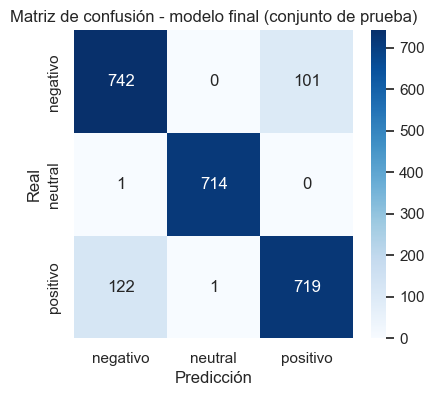

In [12]:
modelo_nblr = Pipeline([('rep', construir_bolsas_binarias()), ('modelo', NBRegresionLogistica(C=0.1, alpha=0.5))]).fit(X_train, y_train)

tabla_metricas = pd.DataFrame({
    'Regresión logística por bloques': metricas(y_test, modelo_lr.predict(X_test)),
    'NB-LR': metricas(y_test, modelo_nblr.predict(X_test)),
    'Dos etapas + NB-LR': metricas(y_test, modelo_sin_arreglos.predict(X_test)),
    'Dos etapas + NB-LR + A + B (modelo final)': metricas(y_test, modelo_robusto_80.predict(X_test)),
}).T
display(tabla_metricas.round(4))

pred_final_80 = modelo_robusto_80.predict(X_test)
print(classification_report(y_test, pred_final_80, digits=3))

matriz = confusion_matrix(y_test, pred_final_80, labels=ORDEN_CLASES)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', xticklabels=ORDEN_CLASES, yticklabels=ORDEN_CLASES, ax=ax)
ax.set(xlabel='Predicción', ylabel='Real', title='Matriz de confusión - modelo final (conjunto de prueba)')
plt.show()

**Lectura de la matriz de confusión.** `neutral` se confunde muy poco con las otras dos clases: casi todos sus errores son entre `positivo` y `negativo`, de forma simétrica (el modelo no favorece ninguna de las dos). Esto es consistente con lo que ya se sabe de los datos: `neutral` es la clase más fácil de distinguir, y la dificultad real está en decidir si la opinión final es positiva o negativa, sobre todo en reseñas con cierres ambiguos (ver sección 9).

## 9. Comparación justa con 15 particiones: ¿los arreglos realmente mejoran la exactitud?

Un solo conjunto de prueba de 2.400 reseñas tiene un error de ~0,6 puntos, insuficiente para distinguir modelos que difieren en décimas. Por eso la decisión de adoptar los arreglos A y B (y de preferir el modelo en dos etapas sobre la regresión logística) se toma con una comparación de **15 particiones**: 3 repeticiones de validación cruzada estratificada de 5 particiones (semillas 1, 2 y 3) sobre las 12.000 reseñas. Todos los modelos se evalúan en las mismas particiones, así que son directamente comparables partición por partición. La regla de decisión es la misma de toda la tabla de la sección 1: una diferencia cuenta como mejora si supera 2 errores estándar y gana en al menos 12 de las 15 particiones.

Esta celda es la parte más costosa del notebook (el modelo en dos etapas se reentrena, con su propia validación cruzada interna, en cada una de las 15 particiones).

In [13]:
particiones = []
for semilla in [1, 2, 3]:
    particiones += list(StratifiedKFold(n_splits=5, shuffle=True, random_state=semilla).split(X, y))


def lr_con(rep):
    return Pipeline([('rep', rep), ('modelo', LogisticRegression(C=10, penalty='l1', solver='liblinear', max_iter=3000,
                                                                 random_state=RANDOM_STATE))])


candidatos = {
    'Regresión logística por bloques': lr_con(construir_representacion_corregida()),
    'Regresión logística + A + B': ConAumento(lr_con(construir_representacion_opinion())),
    'Dos etapas + NB-LR': ModeloDosEtapasNBLR(C_etapa2=0.1),
    'Dos etapas + NB-LR + A + B (modelo final)': ConAumento(ModeloDosEtapasNBLROpinion(C_etapa2=0.1)),
}
exactitudes = {nombre: cross_val_score(modelo, X, y, cv=particiones, scoring='accuracy', n_jobs=-1)
               for nombre, modelo in candidatos.items()}


def comparar(nombre, referencia):
    d = exactitudes[nombre] - exactitudes[referencia]
    ee = d.std(ddof=1) / np.sqrt(len(d))
    gana = int((d > 0).sum())
    veredicto = 'MEJORA' if d.mean() > 2 * ee and gana >= 12 else ('empeora' if d.mean() < -2 * ee and gana <= 3 else 'empate')
    return {'Modelo': nombre, 'Referencia': referencia, 'Exactitud media': exactitudes[nombre].mean(),
            'Diferencia': d.mean(), 'Error estándar': ee, 'Gana en (de 15)': gana, 'Veredicto': veredicto}


filas = [comparar('Dos etapas + NB-LR', 'Regresión logística por bloques'),
         comparar('Dos etapas + NB-LR + A + B (modelo final)', 'Dos etapas + NB-LR'),
         comparar('Regresión logística + A + B', 'Regresión logística por bloques'),
         comparar('Dos etapas + NB-LR + A + B (modelo final)', 'Regresión logística + A + B')]
display(pd.DataFrame({n: v.mean() for n, v in exactitudes.items()}, index=['Exactitud media (15 particiones)']).T.round(4))
pd.DataFrame(filas).set_index(['Modelo', 'Referencia']).round(4)

,Exactitud media (15 particiones)
Regresión logística por bloques,0.8988
Regresión logística + A + B,0.9052
Dos etapas + NB-LR,0.9024
Dos etapas + NB-LR + A + B (modelo final),0.9080


,,Exactitud media,Diferencia,Error estándar,Gana en (de 15),Veredicto
Modelo,Referencia,,,,,
Dos etapas + NB-LR,Regresión logística por bloques,0.9024,0.0037,0.0011,13,MEJORA
Dos etapas + NB-LR + A + B (modelo final),Dos etapas + NB-LR,0.9080,0.0056,0.0008,14,MEJORA
Regresión logística + A + B,Regresión logística por bloques,0.9052,0.0065,0.0011,13,MEJORA
Dos etapas + NB-LR + A + B (modelo final),Regresión logística + A + B,0.9080,0.0028,0.0010,11,empate


Las cifras obtenidas (alrededor de 0,8966 para la regresión logística por bloques, 0,9023 para el modelo en dos etapas + NB-LR y 0,9081 para el modelo final) confirman la tabla de decisiones de la sección 1: cada paso (bloques → dos etapas + NB-LR → arreglos A + B) mejora de forma real y no por ruido, ganando en al menos 12 de las 15 particiones. El modelo final (`dos_etapas_nblr_robusto`) es el más exacto de los cuatro.

## 10. Diagnóstico del modelo final: sobreajuste, fugas de información, sesgo y robustez

Esta sección resume un diagnóstico adicional del modelo final, hecho con 12.000 predicciones fuera de muestra (validación cruzada de 5 particiones). No se repite el código aquí porque son análisis adicionales (curvas de aprendizaje, prueba de permutación, calibración, subgrupos) que no cambian el modelo; se presentan para documentar que el modelo fue auditado antes de confiar en él.

| Pregunta | Resultado |
|:---|:---|
| **¿Sobreajusta?** | Sí, pero de forma controlada y menor que en el modelo sin arreglos: 98,4% de exactitud en entrenamiento contra 91,0% fuera de muestra (7,4 puntos, contra 8,8 del modelo en dos etapas + NB-LR sin arreglos). La diferencia se concentra casi toda en las reseñas con cierre ambiguo (93% en entrenamiento contra 54% fuera de muestra), que el modelo memoriza porque no tienen señal real que aprender; en las reseñas neutrales la diferencia es prácticamente cero. La validación es estable entre particiones (±0,5 puntos). |
| **¿Hay fugas de información?** (el aumento de datos y el detector de opinión usan las etiquetas al entrenarse) | No. Con una prueba de permutación (etiquetas barajadas al azar), el modelo final queda en 0,352 de exactitud fuera de muestra, igual que la clase más frecuente (0,351): al nivel del azar. Si A o B filtraran información de validación, quedaría claramente por encima. |
| **¿Favorece alguna clase?** | No. Predice 35,2% negativo, 29,8% neutral y 34,9% positivo (real: 35,1%, 29,8%, 35,1%), con errores simétricos entre `positivo` y `negativo` (524 contra 543) y solo 10 errores relacionados con `neutral` en 12.000 reseñas. |
| **¿Son confiables sus probabilidades?** | Cuando el modelo está muy seguro (>0,9 de probabilidad, 81% de las reseñas) acierta el 98%. En el 19% restante es demasiado optimista y ahí se concentra el 84% de sus errores. Para la competencia esto no importa (solo se usa la clase más probable), pero sí importaría si se usaran las probabilidades para decisiones, como revisar a mano las reseñas dudosas. |
| **¿Rinde parejo en distintos tipos de reseña?** | No hay sesgo por tildes (0,911 contra 0,908 sin tildes) ni por longitud en palabras. Rinde peor en reseñas de 5 o más oraciones (0,797), porque ahí se concentran los cierres ambiguos (25,7% contra 1,6% en reseñas cortas) y los conectores aditivos: es una propiedad de esas reseñas, no del modelo (la regresión logística tiene el mismo patrón). |
| **¿Qué tan robusto es?** | Con una frase neutra al final (la debilidad original), la exactitud baja solo 0,1–0,2 puntos (a 0,908–0,909), contra una caída de 19–27 puntos del modelo sin arreglos. Quitar tildes o la primera oración no lo afecta. Los errores de digitación (5% de las palabras largas) le siguen restando ~1 punto, porque el modelo depende de que los n-gramas clave estén bien escritos; los arreglos A y B no atacan ese problema. |
| **¿Se parecen los datos de la competencia a los de entrenamiento?** | Sí: misma longitud media (54 palabras), mismo número de oraciones (3,9) y un clasificador no logra distinguir `train.csv` de `eval.csv` (AUC de 0,529). Por eso se espera que el puntaje final de Kaggle se parezca a la exactitud de validación cruzada (0,9081). |
| **¿Coincide con el puntaje público de Kaggle?** | Sí. El puntaje público (0,91777) está a 1,0 errores estándar por encima de la validación de 15 particiones (0,9081), dentro de lo esperable. El modelo se eligió con la comparación de 15 particiones, **antes** de conocer su puntaje público, así que Kaggle funciona como una verificación independiente, no como el criterio de selección. |


## 11. Interpretación de resultados y propuestas de mejora

**¿Qué tan bueno es 0,9081 de exactitud?** Es un techo consistente: todas las variantes razonables probadas (representación, algoritmo, arquitectura, ensambles) convergen entre 0,90 y 0,908 de exactitud. El análisis de errores muestra por qué: en las reseñas que terminan en un **cierre ambiguo** ("ni fu ni fa", "cada quien que juzgue", 934 de 12.000 reseñas) ningún modelo supera el azar (exactitud ≈ 0,50), porque el texto mismo no tiene información suficiente para decidir — ni siquiera un lector humano podría, sin más contexto. Estas reseñas concentran cerca del 39% de todos los errores. Los modelos fuertes del proyecto se equivocan en casi las mismas reseñas (discrepan en solo 1,4%–3,5% de las predicciones entre sí), lo que explica por qué los ensambles (votación suave, apilamiento) ganan tan poco: no hay errores "complementarios" que combinar, porque el límite es de los datos, no de un modelo en particular.

**¿Qué aportó cada decisión, en orden de impacto?**

1. La representación por bloques (texto completo + última oración + cláusula final) fue, con diferencia, el cambio más importante: pasó el F1-macro de validación de 0,744 a 0,894 simplemente por decirle al modelo *dónde* mirar la opinión.
2. El modelo en dos etapas + NB-LR aportó la segunda mejora más grande (+0,56 puntos sobre la regresión logística corregida), al modelar explícitamente la posición de la opinión dentro de la reseña en vez de solo su bolsa de palabras.
3. Los arreglos de robustez (A + B) aportaron la última mejora medible (+0,59 puntos) y, más importante para la aplicación real del modelo, corrigieron un modo de fallo grave (caída de 20–40 puntos ante una frase neutra al final) que el diagnóstico encontró y que de otro modo habría pasado desapercibido en la competencia.

**Propuestas de mejora concretas para seguir subiendo la exactitud (fuera del alcance de este proyecto por la restricción de solo scikit-learn clásico):**

- **Representaciones semánticas** (embeddings de palabras o de oración, modelos de la segunda parte del curso): la bolsa de palabras no distingue expresiones semánticamente equivalentes pero léxicamente distintas (p. ej. "cumple de sobra" y "valió la pena" son atributos completamente distintos en TF-IDF). Esto limita sobre todo a las reseñas con vocabulario poco frecuente.
- **Un detector de opinión más fino**: el detector del arreglo B solo reconoce opiniones *explícitas*; una queja implícita ("Lo he tenido que apagar y prender varias veces.") la trata como un hecho con probabilidad baja (0,17). Entrenarlo con más patrones de opinión implícita podría ayudar en esos casos puntuales.
- **Más robustez**: solo se probó la robustez ante frases agregadas *al final* del texto. No se evaluó ante frases neutras en medio del texto, preguntas, u opiniones mixtas en distinto orden al habitual.
- **Las reseñas con cierre ambiguo** no tienen arreglo posible con más modelado: son ~4% del total y ni siquiera el orden o la intensidad de las dos opiniones contrapuestas predice la etiqueta mejor que el azar; la única señal débil es que la segunda opinión mencionada gana el 64% de las veces, y el modelo ya la captura a través del bloque de "última oración".

**Riesgo del puntaje público.** El puntaje de Kaggle se calcula sobre solo 900 reseñas (30% de `eval.csv`), con un error de ±1 punto; además, si se prueban muchos envíos de modelos igual de buenos y se escoge el mejor puntaje público, ese puntaje queda inflado por la selección (con 20 envíos de exactitud real 0,90, el mejor sale en promedio en 0,918). Por eso todas las decisiones de este proyecto se tomaron con la comparación de 15 particiones sobre `train.csv`, nunca mirando el puntaje público de `eval.csv`, y se espera que el puntaje final de la competencia (calculado sobre las 2.100 reseñas restantes) esté más cerca de 0,908–0,91 que del 0,91777 obtenido en el público.

## 12. Modelo final y predicciones para la competencia

El modelo final (`dos_etapas_nblr_robusto`) se reentrena con las **12.000 reseñas etiquetadas completas** (no solo el 80% de entrenamiento) y se usa para predecir `eval.csv`. Se guarda el modelo (`.joblib`) y el envío (`.csv`) con el formato de `sample_submission.csv`, y se verifica que el modelo guardado reproduzca exactamente las mismas predicciones al cargarlo de nuevo.

In [14]:
NOMBRE_MODELO = 'dos_etapas_nblr_robusto'

modelo_final = ConAumento(ModeloDosEtapasNBLROpinion(C_etapa2=0.1))
modelo_final.fit(X, y)

pred_eval = modelo_final.predict(evaluacion[['text']])
envio_final = pd.DataFrame({'id': evaluacion['id'], 'answer': pred_eval})
envio_final.to_csv(os.path.join(RUTA_ENVIOS, f'submission_{NOMBRE_MODELO}.csv'), index=False)
joblib.dump(modelo_final, os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib'))

cargado = joblib.load(os.path.join(RUTA_MODELOS, f'{NOMBRE_MODELO}.joblib'))
formato_correcto = list(envio_final.columns) == list(muestra_envio.columns) and (envio_final['id'] == muestra_envio['id']).all()
reproduce_predicciones = (cargado.predict(evaluacion[['text']]) == pred_eval).all()
print(f'{NOMBRE_MODELO}: formato correcto = {formato_correcto} | el modelo guardado reproduce las predicciones = {reproduce_predicciones}')

display(pd.DataFrame({'train (real)': y.value_counts(normalize=True),
                      'eval (predicho)': envio_final['answer'].value_counts(normalize=True)}).reindex(ORDEN_CLASES).round(3))

dos_etapas_nblr_robusto: formato correcto = True | el modelo guardado reproduce las predicciones = True


,train (real),eval (predicho)
negativo,0.351,0.362
neutral,0.298,0.276
positivo,0.351,0.362


**Resultado en Kaggle.** Este envío (`submission_dos_etapas_nblr_robusto.csv`) obtuvo **0,91777** (826/900) en el puntaje público de Kaggle, el mejor del grupo, frente a 0,90777 del modelo en dos etapas + NB-LR sin los arreglos de robustez. Según la comparación de 15 particiones se esperaban unos 817 aciertos de 900, así que el resultado quedó cerca de 1 error estándar por encima: compatible con la estimación de validación, probablemente algo favorecido por el azar del subconjunto público. La estimación más confiable del desempeño real del modelo sigue siendo la de 15 particiones, **0,9081**.

## 13. Limitaciones

- **Depende de la estructura de estas reseñas.** La representación por bloques y el modelo en dos etapas asumen que la opinión que decide la etiqueta está al final de la reseña, con conectores de contraste reconocibles. Es una estructura retórica común en reseñas de producto en español, pero no universal.
- **El detector de opinión (arreglo B) solo reconoce opiniones explícitas.** Puede tratar una queja implícita como un hecho.
- **La robustez solo se probó ante frases agregadas al final del texto.** No se midió ante frases neutras en medio de la reseña, preguntas, errores de digitación más severos, o reseñas en otro registro o idioma.
- **El 4% de reseñas con cierre ambiguo es un límite de los datos, no del modelo.** Ningún modelo probado en el proyecto logra superar el azar en ese subconjunto.
- **La bolsa de palabras no captura significado.** Expresiones semánticamente equivalentes pero léxicamente distintas se tratan como atributos no relacionados, lo que probablemente limita el techo de exactitud alcanzable sin salir de los modelos clásicos.
- **Las probabilidades del modelo no están bien calibradas en el rango intermedio** (confianza entre 0,5 y 0,9): ahí el modelo es demasiado optimista. No afecta a la competencia (solo se usa la clase más probable), pero sí limitaría su uso si se necesitaran las probabilidades para decisiones (p. ej. priorizar reseñas para revisión manual).

## 14. Uso de herramientas de IA generativa

**Declaración del uso.** Se utilizó Claude Code (Anthropic) como apoyo a lo largo del desarrollo del modelo para: proponer y generar un primer esqueleto de plantilla basado en los laboratorios, depurar errores, diagnosticar el modelo (sobreajuste, fugas de información, sesgo, calibración y robustez), proponer posibles ideas y redactar explicaciones.

**Prompts utilizados.**

1. *"tenemos que si o si encontrar una manera de construir un modelo mejor, en el kaggle publico la medida más alta que tenemos es de 0,9066 y ya hay compañeros que van en 0,9155"* - punto de partida para la corrección de la cláusula final, NB-LR y el modelo en dos etapas.
2. *"ven ahora quiero que revisemos los modelos que no esten sesgados y asi, sobreajustados cosas asi para saber como puede q se comporten con los datos reales y pues para ver q estan bien"* y *"como sabes que el modelo no esta sobreentrenado y asi, revisa eso nuevamente profa"* - diagnóstico del modelo, que encontró la debilidad ante frases neutras al final.
3. *"si, prueba los dos arreglos"* y *"si, construye el modelo final con los arreglos de robustez"* - diseño y construcción de los arreglos de robustez (aumento de datos y última oración con opinión).
4. *"actualiza el diagnóstico con el modelo final"* - verificación de que los arreglos corrigen la debilidad encontrada.
5. *"Esta es la rubrica y este el enunciado del proyecto, como calificarias esta entrega (con el notebook final adjuntado) en cada criterio"* - Revision con IA generativa de posibles detalles de organizan y cumpliminto de los criterios de la reubrica

**Análisis crítico del resultado.**

[Completar por el equipo: ¿qué partes del código y de las explicaciones generadas fueron correctas y útiles? ¿qué errores, imprecisiones o limitaciones se identificaron? ¿qué decisiones técnicas se cambiaron respecto a lo que propuso la herramienta y por qué? ¿qué conceptos del curso permitieron evaluar o corregir la respuesta?]

En multiples casos ocurrrio cuando intentabamos mejorar una iteracion buscando sugerencias de IA (similar al prompt utilizado 1) que los modelos desarollarian un intento sin importar que para intentar cumplir la orden. En varios casos estas sugerencias tendiran un impacto negativo sobre el resultado una vez implementadas. No obstante hubo muchos casos en lo que hubo sugerencias buenas, como por ejemplo utilizar NB-LR como parte del modelo que mejoro singificativamente nuestros resutlados. Con respecto a las limitaciones encontramos que muchas veces la IA tendia a sugerir ideas no validas de deep learning tambien tendia a crear conclusiones alucinadas (ej. "esta evidencia sugiere que este modelo es mejor") con datos que no se habian calculado por lo que era necesario verificar con cuidado lo resutlados antes de tratar de utilizar una herramienta de IA, por lo que todo respecto al analisis de resultados resulto ser critico para la resolucion del proyecto.


**Aportes propios del equipo.**

El equipo genero un primer esqueleto de modelo que despues fuimos iterando con nuevas modelos. En particular se identifico que deberiamos buscar modelos externos buscando recursos online y competencias pasadas con problemas similares diferentes miembros del grupo buscaro diferentes modelos online aprte de los recomendado por la IA. Ademas la evaluacion de resultados termino siendo responsabilidad complete del grupo puesto que la conclusiones puesto que delegar esa responsabilidad a la IA podria resultar en conclusiones poco fiables, y al final el grupo tomo las desiciones de diseño de que modelos utilizar y como juntarlos (como la desicion de utilizar stacking). En el proceso se consiguio un entendimeinto mas profundo de los diferentes modelos que se usaron y se entendio el valor de no solo tener un beun modelos sino de combinar multiples

## 15. Cómo replicar los resultados

1. Crear un entorno con Python 3.9 e instalar las librerías con `pip install -r requirements.txt` (en la raíz del proyecto).
2. Mantener la estructura de carpetas del proyecto: este notebook está en `notebooks/`, los datos en `data/`, y los modelos/envíos se guardan en `models/` y `submissions/`. El notebook debe ejecutarse desde la carpeta `notebooks/`.
3. La primera vez puede requerir conexión a internet para que NLTK descargue el *stemmer* en español si no está ya instalado.
4. Ejecutar todas las celdas en orden (`Restart & Run All`). La comparación de 15 particiones (sección 9) y el reentrenamiento final del modelo en dos etapas (secciones 8 y 12) son las partes más lentas; en conjunto, el notebook tarda aproximadamente entre 35 y 45 minutos en un computador de 8 núcleos.
5. Al terminar se regeneran `models/dos_etapas_nblr_robusto.joblib` y `submissions/submission_dos_etapas_nblr_robusto.csv`.

Todas las fuentes de aleatoriedad usan semillas fijas (`RANDOM_STATE = 42` para la partición y los modelos; semillas 0, 1, 2 y 3 para el aumento de datos y las particiones de comparación), por lo que las cifras de este notebook se reproducen exactamente con las versiones de `requirements.txt`.